In [27]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('Powerplant.csv')

In [3]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [4]:
# AT => Temperature
# V => Vacuum
# AP => Pressure
# PE => Produced energy

In [5]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [6]:
X = df.drop("PE", axis=1)
y = df["PE"]

In [7]:
X.head()

,AT,V,AP,RH
0,8.34,40.77,1010.84,90.01
1,23.64,58.49,1011.40,74.20
2,29.74,56.90,1007.15,41.91
3,19.07,49.69,1007.22,76.79
4,11.80,40.66,1017.13,97.20


In [8]:
from sklearn.model_selection import train_test_split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y, test_size=0.2, random_state=42
)

In [10]:
X_train.shape

(7654, 4)

In [11]:
df.shape

(9568, 5)

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
import torch
import torch.nn as nn

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

In [14]:
type(X_train_scaled)

numpy.ndarray

In [15]:
type(y_train)

pandas.core.series.Series

In [28]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor) # Create a dataset of X_train tensor and Y_train tensor 
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [17]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size=32)

## Deep Learning

In [18]:
# Define our ANN Model
class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        self.model = nn.Sequential(
            #1 hidden layer
            nn.Linear(4, 6),  # 4 input and 6 output in 1st hidden layer
            nn.ReLU(),

            # 2 hidden layer
            nn.Linear(6,6),  # 6 input from 1 layer and there will be  6 output in 2nd hidden layer
            nn.ReLU(),

            # Output Layer
            nn.Linear(6, 1),
        )

    def forward(self, x):
       return self.model(x)

In [31]:
import torch.optim as optim

model  = ANN()

# Loss Function, Optimizer
crietrion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())
# Optimizer are use to update the weight and bias 
# model.parameters() => it provide the parameter(weight & bias) on which  
# model has train and now adam will update them  

In [20]:
# Train the ANN

train_losses = []
val_losses = []

best_val_loss = float("inf")
epochs = 100

for epoch in range(epochs):
    model.train()
    running_loss = 0.0 # total training loss for 1 batch

    for xb, yb in train_loader:
        # xb => feature of 1 batch 
        # yb => label of 1 batch
        optimizer.zero_grad()

        outputs = model(xb)  # forward propagation ... predict output for this batch
# Basically ham yaha pe model ko input diye hai output predict karne ke liye same like we din in ML with predict func
        loss = crietrion(outputs, yb)  # Compute loss
        # Here it is comparing the output with real output
        loss.backward() # back propagation
        optimizer.step() # Params update 
        running_loss += loss.item() # loss in tensor => py float

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)

    # Validation

    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():

        for xb, yb in test_loader:
            outputs = model(xb)
            loss = crietrion(outputs, yb)
            running_val_loss += loss

    epoch_val_loss =running_val_loss/ len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch ${epoch+1}/{epochs} ==> train loss = ${epoch_train_loss} & val loss = ${epoch_val_loss}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt") #use .pt or pth

epoch $1/100 ==> train loss = $205205.26067708334 & val loss = $201478.71875
epoch $2/100 ==> train loss = $189574.2994140625 & val loss = $171071.671875
epoch $3/100 ==> train loss = $143737.8650716146 & val loss = $114228.0
epoch $4/100 ==> train loss = $89226.13154296875 & val loss = $69307.5546875
epoch $5/100 ==> train loss = $55117.931315104164 & val loss = $43874.16015625
epoch $6/100 ==> train loss = $33040.59101969401 & val loss = $24380.53125
epoch $7/100 ==> train loss = $17200.213049316408 & val loss = $12426.4580078125
epoch $8/100 ==> train loss = $9102.25742594401 & val loss = $7309.2021484375
epoch $9/100 ==> train loss = $5753.673320515951 & val loss = $5028.42626953125
epoch $10/100 ==> train loss = $4097.090626017252 & val loss = $3650.464111328125
epoch $11/100 ==> train loss = $3010.6232660929363 & val loss = $2669.45361328125
epoch $12/100 ==> train loss = $2203.0808214823405 & val loss = $1967.1507568359375
epoch $13/100 ==> train loss = $1631.0225222269694 & val

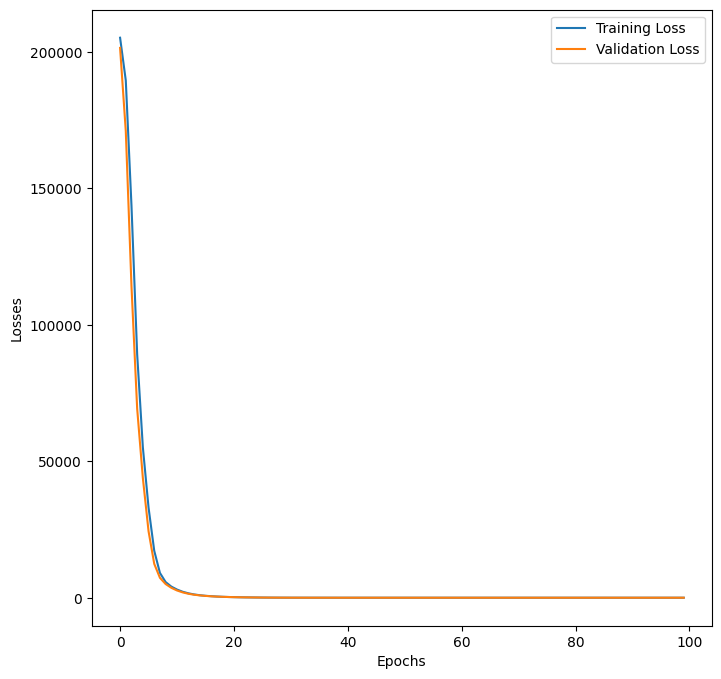

In [21]:
# Plot the graph 

loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss": val_losses
})

plt.figure(figsize=(8,8))
plt.plot(loss_df["Training Loss"], label="Training Loss")
plt.plot(loss_df["Validation Loss"], label="Validation Loss")



plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

In [22]:
print(best_val_loss)

tensor(18.5340)


In [23]:
# Loading the best model

model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [24]:
# Model evaluation

model.eval()
with torch.no_grad():
    train_pred =model(X_train_tensor)
    test_pred = model(X_test_tensor)

    train_mse_loss = crietrion(train_pred, y_train_tensor) # It predict for full training dataset
    test_mse_loss  = crietrion(test_pred, y_test_tensor)

print("Training MSE:", train_mse_loss.item())
print("Testing MSE Loss :", test_mse_loss.item())

Training MSE: 20.295490264892578
Testing MSE Loss : 18.536672592163086


In [25]:
from sklearn.metrics import r2_score

print("R2 Score :" , r2_score(y_test, test_pred)*100)

R2 Score : 93.52191162577164


In [26]:
predicted_df = pd.DataFrame(test_pred.numpy(), columns=["Predicted Values"])
actual_df = pd.DataFrame(y_test.values, columns=["Actual Values"])

pd.concat([predicted_df, actual_df], axis=1)

,Predicted Values,Actual Values
0,435.251373,433.27
1,436.294861,438.16
2,461.024414,458.42
3,475.921570,480.82
4,434.815369,441.41
...,...,...
1909,451.242737,456.70
1910,431.248291,438.04
1911,467.780640,467.80
1912,430.530273,437.14
